# ANCOVA – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/ancova)

Die **ANCOVA** (Analysis of Covariance, Kovarianzanalyse) kombiniert
**ANOVA + Regression**: Sie vergleicht Gruppenmittelwerte und rechnet dabei
gleichzeitig den Einfluss einer oder mehrerer **Kovariaten** heraus.

**Modell:**
$$y_{ij} = \mu + \alpha_j + \beta \cdot (x_{ij} - \bar{x}) + \varepsilon_{ij}$$

| Symbol | Bedeutung |
|---|---|
| $y_{ij}$ | AV (Prüfungsergebnis) |
| $\alpha_j$ | Haupteffekt Gruppe $j$ |
| $\beta$ | Regressionskoeffizient der Kovariate |
| $x_{ij}$ | Kovariate (z. B. Vortest-Note) |
| $\varepsilon_{ij}$ | Fehler (Residuum) |

**ANOVA vs. ANCOVA:**

| | ANOVA | ANCOVA |
|---|---|---|
| Fragestellung | Hat die Gruppe Einfluss auf AV? | Hat die Gruppe Einfluss, **nachdem** Kovariate kontrolliert wurde? |
| Kovariaten | Nein | Ja (eine oder mehrere) |
| Vorteil | Einfacher | Erhöhte Teststärke, fairerer Vergleich |

**Voraussetzungen:**
1. AV metrisch, Gruppe nominal
2. Lineare Beziehung zwischen Kovariate und AV
3. **Homogenität der Regressionssteigungen** – Kovariate wirkt in allen Gruppen gleich
4. Normalverteilung der Residuen
5. Unabhängigkeit der Beobachtungen

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

try:
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm
    HAS_SM = True
except ImportError:
    HAS_SM = False

np.random.seed(42)
print("Bibliotheken geladen. statsmodels:", HAS_SM)

Bibliotheken geladen. statsmodels: True


## 1. Warum ANCOVA? Das Problem ohne Kovariate

**Beispiel (numiqo):** Drei Lernmethoden A, B, C – welche führt zu besseren
Prüfungsergebnissen?

**Problem:** Gruppe B hatte zufällig bessere Vortest-Noten. Ohne Kovariate
sieht Methode B besser aus – obwohl der Unterschied nur am Vorwissen liegt.

**ANCOVA löst das:** Sie rechnet den Vortest-Effekt heraus und vergleicht die
Gruppen auf einem **einheitlichen Vorwissensstand** (adjusted means).

ANOVA (ohne Kovariate)
Gruppe A: MW Vortest=53.5, MW Prüfung=57.3
Gruppe B: MW Vortest=64.0, MW Prüfung=66.3
Gruppe C: MW Vortest=58.1, MW Prüfung=63.1
F=13.294, p=0.0000
-> B scheint besser, aber liegt das an der Methode oder am Vorwissen?


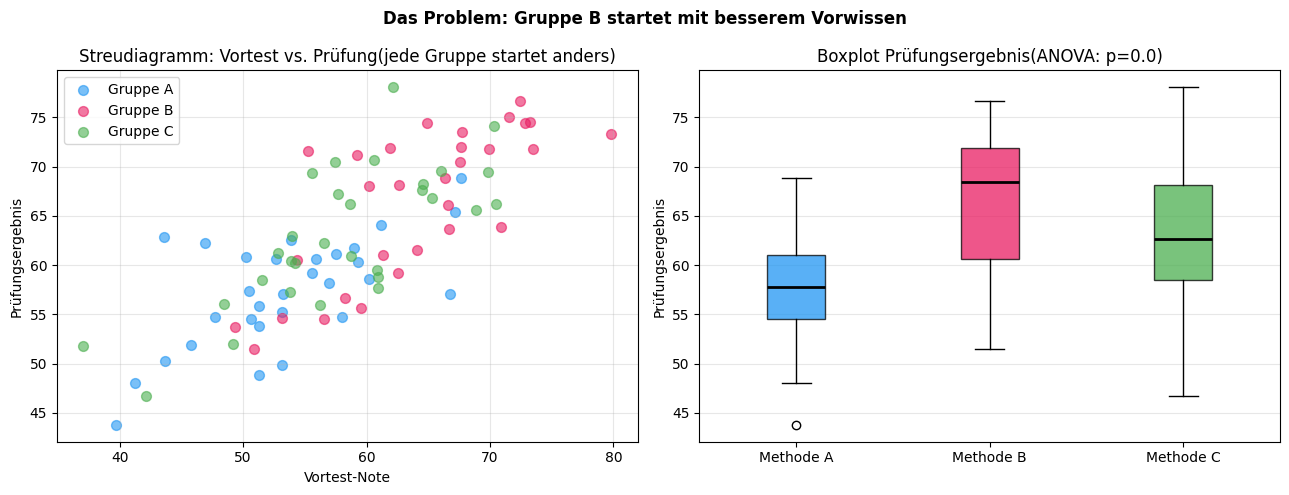

In [2]:
# Motivation: ANOVA vs. ANCOVA
np.random.seed(42)
n_pro = 30

# Vortest-Noten – Gruppe B hat systematisch höhere Ausgangswerte
vortest_a = np.random.normal(55, 8, n_pro)
vortest_b = np.random.normal(65, 8, n_pro)  # Gruppe B startet besser
vortest_c = np.random.normal(58, 8, n_pro)

# Prüfungsergebnis: Vortest wirkt stark (beta=0.7), Methode kaum
beta = 0.7
noise = 5
pruef_a = 20 + beta * vortest_a + np.random.normal(0, noise, n_pro)
pruef_b = 22 + beta * vortest_b + np.random.normal(0, noise, n_pro)
pruef_c = 21 + beta * vortest_c + np.random.normal(0, noise, n_pro)

df = pd.DataFrame({
    "Prüfung": np.concatenate([pruef_a, pruef_b, pruef_c]),
    "Vortest":  np.concatenate([vortest_a, vortest_b, vortest_c]),
    "Gruppe":   ["A"]*n_pro + ["B"]*n_pro + ["C"]*n_pro
})

# ANOVA (ohne Kovariate)
F_anova, p_anova = stats.f_oneway(pruef_a, pruef_b, pruef_c)

print("ANOVA (ohne Kovariate)")
print(f"Gruppe A: MW Vortest={vortest_a.mean():.1f}, MW Prüfung={pruef_a.mean():.1f}")
print(f"Gruppe B: MW Vortest={vortest_b.mean():.1f}, MW Prüfung={pruef_b.mean():.1f}")
print(f"Gruppe C: MW Vortest={vortest_c.mean():.1f}, MW Prüfung={pruef_c.mean():.1f}")
print(f"F={F_anova:.3f}, p={p_anova:.4f}")
print("-> B scheint besser, aber liegt das an der Methode oder am Vorwissen?")

# Visualisierung: Problem
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Das Problem: Gruppe B startet mit besserem Vorwissen",
             fontsize=12, fontweight="bold")

farben = {"A": "#2196F3", "B": "#E91E63", "C": "#4CAF50"}
for grp, fc in farben.items():
    maske = df["Gruppe"] == grp
    axes[0].scatter(df[maske]["Vortest"], df[maske]["Prüfung"],
                    color=fc, alpha=0.6, s=50, label="Gruppe " + grp)
axes[0].set_title("Streudiagramm: Vortest vs. Prüfung(jede Gruppe startet anders)")
axes[0].set_xlabel("Vortest-Note")
axes[0].set_ylabel("Prüfungsergebnis")
axes[0].legend()
axes[0].grid(alpha=0.3)

bp = axes[1].boxplot([pruef_a, pruef_b, pruef_c], patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
for patch, fc in zip(bp["boxes"], farben.values()):
    patch.set_facecolor(fc); patch.set_alpha(0.75)
axes[1].set_title("Boxplot Prüfungsergebnis(ANOVA: p=" + str(round(p_anova, 4)) + ")")
axes[1].set_ylabel("Prüfungsergebnis")
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(["Methode A", "Methode B", "Methode C"])
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 2. ANCOVA berechnen

Die ANCOVA läuft als lineares Modell mit Gruppe + Kovariate:

```
Prüfung ~ Gruppe + Vortest
```

**Adjusted Means** (bereinigte Mittelwerte): Mittelwert jeder Gruppe,
wenn alle Personen denselben Vortest-Wert gehabt hätten (= Gesamtmittelwert
der Kovariate).

In [3]:
if HAS_SM:
    # ANCOVA via statsmodels
    model = ols("Prüfung ~ C(Gruppe) + Vortest", data=df).fit()
    ancova_tab = anova_lm(model, typ=2)

    print("ANCOVA: Prüfung ~ Gruppe + Vortest")
    print(ancova_tab.round(4))
    print()

    # Adjusted Means berechnen
    vortest_mean = df["Vortest"].mean()
    adj_means = {}
    for grp in ["A", "B", "C"]:
        # Adjusted mean = intercept + Gruppeneffekt + beta * Vortest_gesamt_mean
        pred_df = pd.DataFrame({"Gruppe": [grp], "Vortest": [vortest_mean]})
        adj_means[grp] = model.predict(pred_df).values[0]

    print("Adjusted Means (bereinigt um Vortest)")
    print(f"Gruppe A: {adj_means['A']:.2f}")
    print(f"Gruppe B: {adj_means['B']:.2f}")
    print(f"Gruppe C: {adj_means['C']:.2f}")
    print()
    print("Zum Vergleich – Rohe Mittelwerte:")
    for grp, arr in [("A", pruef_a), ("B", pruef_b), ("C", pruef_c)]:
        print(f"Gruppe {grp}: {arr.mean():.2f}")
    print()
    print("-> Nach Korrektur sind die Gruppen nahe beieinander!")

else:
    # Manuelle ANCOVA via scipy (einfaches Modell)
    from scipy.stats import pearsonr
    print("statsmodels nicht verfügbar. Manuelle Berechnung:")
    r_av, _ = pearsonr(df["Vortest"], df["Prüfung"])
    print(f"Korrelation Vortest-Prüfung: r={r_av:.3f}")
    print("(Hohe Korrelation besätigt: Kovariate ist relevant)")

ANCOVA: Prüfung ~ Gruppe + Vortest
              sum_sq    df        F  PR(>F)
C(Gruppe)   109.2537   2.0   2.3526  0.1012
Vortest    2077.6706   1.0  89.4778  0.0000
Residual   1996.9162  86.0      NaN     NaN

Adjusted Means (bereinigt um Vortest)
Gruppe A: 60.62
Gruppe B: 62.79
Gruppe C: 63.35

Zum Vergleich – Rohe Mittelwerte:
Gruppe A: 57.35
Gruppe B: 66.35
Gruppe C: 63.07

-> Nach Korrektur sind die Gruppen nahe beieinander!


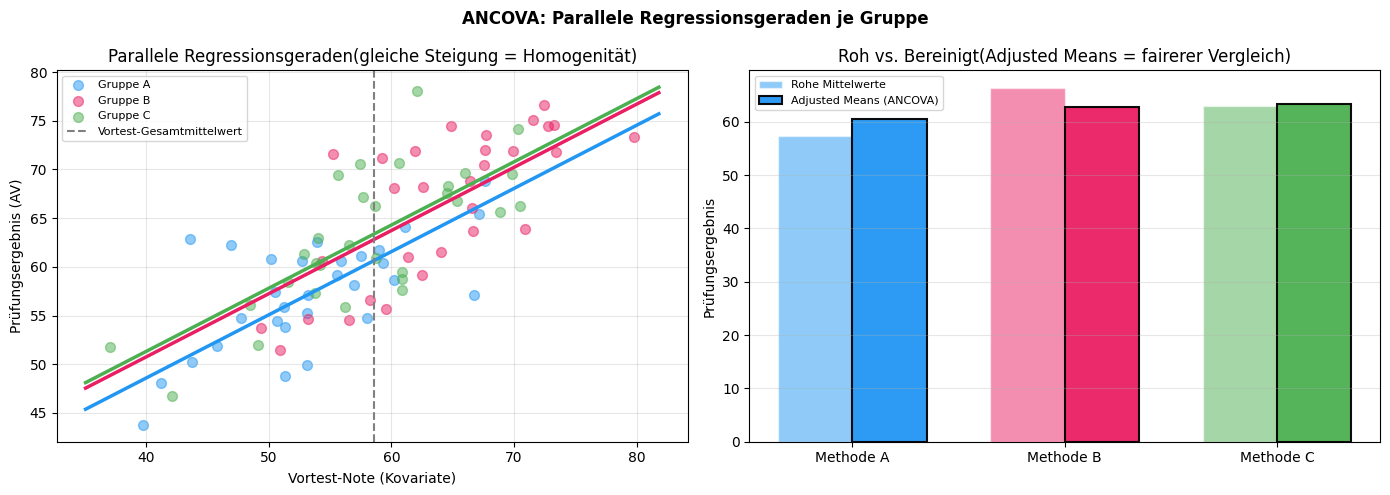

In [4]:
# ANCOVA-Visualisierung: parallele Regressionsgeraden
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ANCOVA: Parallele Regressionsgeraden je Gruppe", fontsize=12, fontweight="bold")

x_range = np.linspace(df["Vortest"].min()-2, df["Vortest"].max()+2, 100)

for grp, fc in farben.items():
    maske = df["Gruppe"] == grp
    d_grp = df[maske]
    axes[0].scatter(d_grp["Vortest"], d_grp["Prüfung"],
                    color=fc, alpha=0.5, s=50, label="Gruppe " + grp)

    if HAS_SM:
        pred_line = pd.DataFrame({"Gruppe": [grp]*100, "Vortest": x_range})
        y_line = model.predict(pred_line)
        axes[0].plot(x_range, y_line, color=fc, linewidth=2.5)
    else:
        m, b = np.polyfit(d_grp["Vortest"], d_grp["Prüfung"], 1)
        axes[0].plot(x_range, m*x_range + b, color=fc, linewidth=2.5)

axes[0].axvline(df["Vortest"].mean(), color="gray", linestyle="--",
                linewidth=1.5, label="Vortest-Gesamtmittelwert")
axes[0].set_title("Parallele Regressionsgeraden(gleiche Steigung = Homogenität)")
axes[0].set_xlabel("Vortest-Note (Kovariate)")
axes[0].set_ylabel("Prüfungsergebnis (AV)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Adjusted Means vs. Rohe Mittelwerte
x_pos = [0, 1, 2]
breite = 0.35
rohwerte = [pruef_a.mean(), pruef_b.mean(), pruef_c.mean()]

if HAS_SM:
    adj_werte = [adj_means["A"], adj_means["B"], adj_means["C"]]
else:
    # Näherung ohne statsmodels
    b_cov = np.polyfit(df["Vortest"], df["Prüfung"], 1)[0]
    adj_werte = [rohwerte[i] - b_cov*(np.mean([vortest_a,vortest_b,vortest_c][i])
                  - df["Vortest"].mean()) for i in range(3)]

axes[1].bar([p - breite/2 for p in x_pos], rohwerte, breite,
            color=list(farben.values()), alpha=0.5, edgecolor="white",
            label="Rohe Mittelwerte")
axes[1].bar([p + breite/2 for p in x_pos], adj_werte, breite,
            color=list(farben.values()), alpha=0.95, edgecolor="black",
            linewidth=1.5, label="Adjusted Means (ANCOVA)")
axes[1].set_title("Roh vs. Bereinigt(Adjusted Means = fairerer Vergleich)")
axes[1].set_ylabel("Prüfungsergebnis")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(["Methode A", "Methode B", "Methode C"])
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Voraussetzung: Homogenität der Regressionssteigungen

**Kritischste Voraussetzung der ANCOVA!**

Die Kovariate muss in **allen Gruppen** denselben Effekt haben (parallele Linien).
Wenn sich die Steigungen unterscheiden, liegt eine **Interaktion** zwischen
Gruppe und Kovariate vor – dann ist die ANCOVA nicht mehr sinnvoll.

**Prüfung:** Modell mit Interaktionsterm `Gruppe × Kovariate` testen:
- Interaktion n.s. (p > 0,05) → Homogenität gegeben → ANCOVA OK
- Interaktion sig. (p < 0,05) → ANCOVA **nicht** sinnvoll

Test auf Homogenität der Steigungen
Modell mit Interaktion: Gruppe * Vortest

                      sum_sq    df        F  PR(>F)
C(Gruppe)           109.2537   2.0   2.3608  0.1006
Vortest            2077.6706   1.0  89.7908  0.0000
C(Gruppe):Vortest    53.2385   2.0   1.1504  0.3214
Residual           1943.6776  84.0      NaN     NaN

Interaktion C(Gruppe):Vortest: p=0.3214
-> p > 0.05: Homogenität gegeben -> ANCOVA ist zulässig!


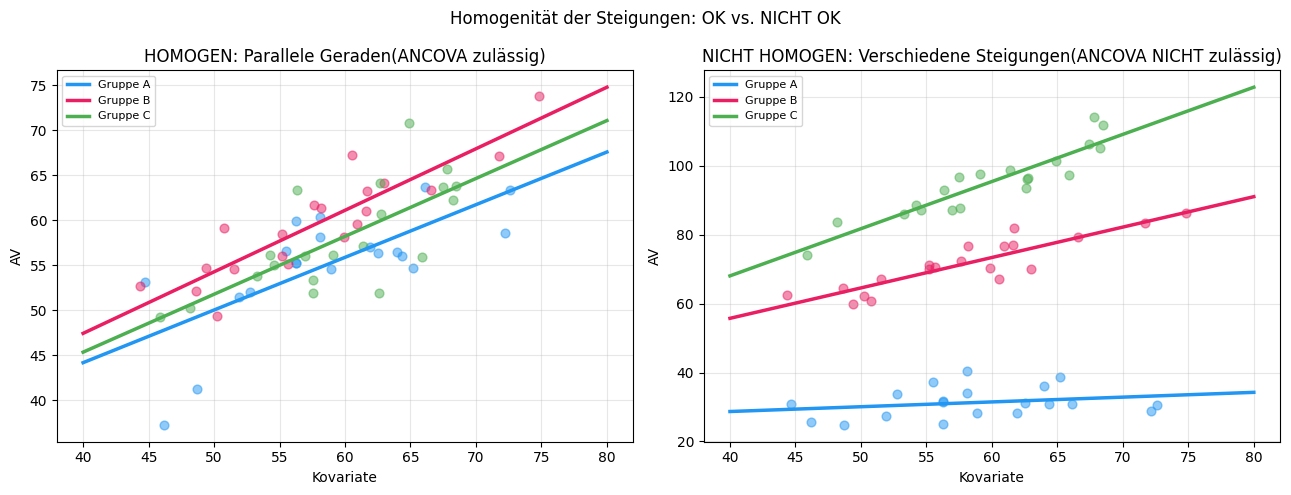

In [7]:
# Homogenität der Steigungen prüfen
if HAS_SM:
    # Modell MIT Interaktion
    model_int = ols("Prüfung ~ C(Gruppe) * Vortest", data=df).fit()
    tab_int   = anova_lm(model_int, typ=2)

    print("Test auf Homogenität der Steigungen")
    print("Modell mit Interaktion: Gruppe * Vortest")
    print()
    print(tab_int.round(4))
    print()

    p_int = tab_int.loc["C(Gruppe):Vortest", "PR(>F)"]
    print(f"Interaktion C(Gruppe):Vortest: p={p_int:.4f}")
    if p_int > 0.05:
        print("-> p > 0.05: Homogenität gegeben -> ANCOVA ist zulässig!")
    else:
        print("-> p < 0.05: KEINE Homogenität -> ANCOVA nicht sinnvoll!")

# Visualisierung: homogen vs. nicht homogen
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Homogenität der Steigungen: OK vs. NICHT OK", fontsize=12)

np.random.seed(42)
n_h = 20

# Homogen: gleiche Steigungen
x_h = np.random.normal(60, 8, 3*n_h)
g_h = ["A"]*n_h + ["B"]*n_h + ["C"]*n_h
y_h_A = 20 + 0.6*x_h[:n_h]    + np.random.normal(0, 4, n_h)
y_h_B = 25 + 0.6*x_h[n_h:2*n_h] + np.random.normal(0, 4, n_h)
y_h_C = 22 + 0.6*x_h[2*n_h:]  + np.random.normal(0, 4, n_h)

# Nicht homogen: verschiedene Steigungen
y_nh_A = 20 + 0.2*x_h[:n_h]    + np.random.normal(0, 4, n_h)
y_nh_B = 25 + 0.8*x_h[n_h:2*n_h] + np.random.normal(0, 4, n_h)
y_nh_C = 22 + 1.2*x_h[2*n_h:]  + np.random.normal(0, 4, n_h)

x_r = np.linspace(40, 80, 100)
for ax, ys, titel in zip(axes,
    [(y_h_A, y_h_B, y_h_C), (y_nh_A, y_nh_B, y_nh_C)],
    ["HOMOGEN: Parallele Geraden(ANCOVA zulässig)",
     "NICHT HOMOGEN: Verschiedene Steigungen(ANCOVA NICHT zulässig)"]
):
    for y_g, grp, fc in zip(ys, ["A","B","C"], farben.values()):
        x_g = x_h[:n_h] if grp == "A" else (x_h[n_h:2*n_h] if grp == "B" else x_h[2*n_h:])
        ax.scatter(x_g, y_g, color=fc, alpha=0.5, s=40)
        m, b = np.polyfit(x_g, y_g, 1)
        ax.plot(x_r, m*x_r + b, color=fc, linewidth=2.5, label="Gruppe " + grp)
    ax.set_title(titel)
    ax.set_xlabel("Kovariate")
    ax.set_ylabel("AV")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Vollständiges Beispiel: Blutdruck-Therapie

**Drei Therapien A, B, C** – Blutdrucksenkung (AV).
**Kovariate:** Ausgangs-Blutdruck (Baseline) vor der Therapie.

Personen mit höherem Ausgangs-Blutdruck haben mehr Spielraum zur Senkung –
diesen Effekt rechnen wir heraus.

Blutdruck-Therapie
  Therapie    MW Baseline   MW Senkung
         A          140.6         17.6
         B          145.1         15.4
         C          143.4         14.5

ANOVA (ohne Kovariate): F=1.217, p=0.3021

ANCOVA
                sum_sq    df         F  PR(>F)
C(Therapie)   335.1645   2.0   14.8258     0.0
Baseline     3070.2631   1.0  271.6216     0.0
Residual      802.5454  71.0       NaN     NaN

Adjusted Means (Baseline=143.1 mmHg):
  Therapie A: 18.85 mmHg
  Therapie B: 14.33 mmHg
  Therapie C: 14.31 mmHg


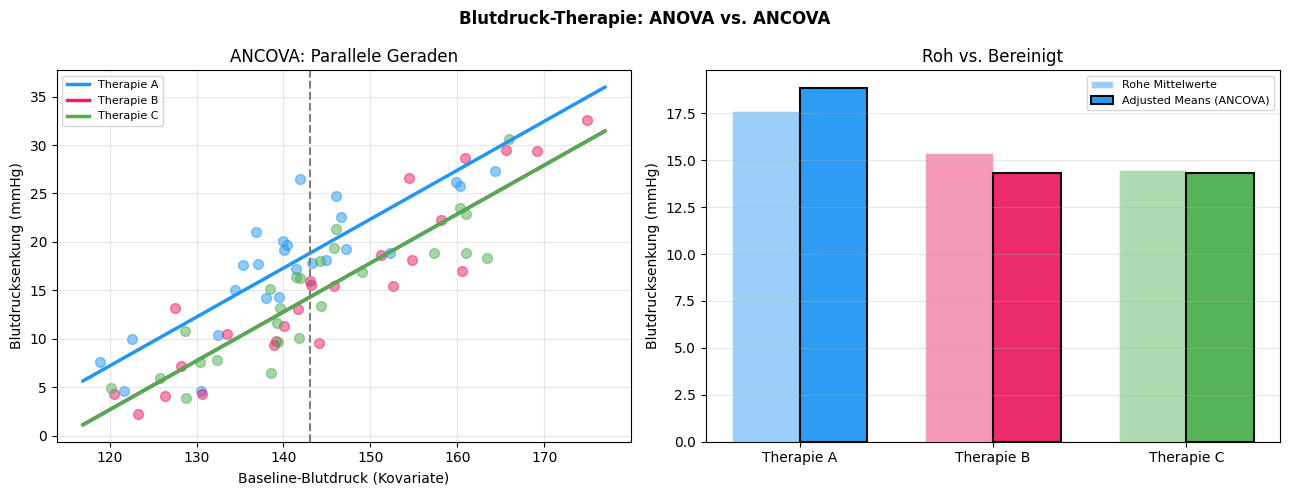

In [8]:
np.random.seed(7)
n_bp = 25

# Baseline variiert zwischen Gruppen
baseline_a = np.random.normal(140, 12, n_bp)
baseline_b = np.random.normal(148, 12, n_bp)  # B hat höhere Ausgangswerte
baseline_c = np.random.normal(143, 12, n_bp)

# Senkung: Methode A am besten (nach Korrektur)
beta_bl = 0.5
senkung_a = 18 + beta_bl*(baseline_a - 143) + np.random.normal(0, 4, n_bp)
senkung_b = 14 + beta_bl*(baseline_b - 143) + np.random.normal(0, 4, n_bp)
senkung_c = 16 + beta_bl*(baseline_c - 143) + np.random.normal(0, 4, n_bp)

df_bp = pd.DataFrame({
    "Senkung":   np.concatenate([senkung_a, senkung_b, senkung_c]),
    "Baseline":  np.concatenate([baseline_a, baseline_b, baseline_c]),
    "Therapie":  ["A"]*n_bp + ["B"]*n_bp + ["C"]*n_bp
})

# ANOVA (ohne Kovariate)
F_bp, p_bp = stats.f_oneway(senkung_a, senkung_b, senkung_c)

print("Blutdruck-Therapie")
print(f"{'Therapie':>10} {'MW Baseline':>14} {'MW Senkung':>12}")
for name, bl, s in [("A", baseline_a, senkung_a),
                     ("B", baseline_b, senkung_b),
                     ("C", baseline_c, senkung_c)]:
    print(f"{name:>10} {bl.mean():>14.1f} {s.mean():>12.1f}")
print()
print(f"ANOVA (ohne Kovariate): F={F_bp:.3f}, p={p_bp:.4f}")

if HAS_SM:
    model_bp  = ols("Senkung ~ C(Therapie) + Baseline", data=df_bp).fit()
    tab_bp    = anova_lm(model_bp, typ=2)
    print()
    print("ANCOVA")
    print(tab_bp.round(4))
    print()

    # Adjusted means
    bl_mean = df_bp["Baseline"].mean()
    print("Adjusted Means (Baseline=" + str(round(bl_mean, 1)) + " mmHg):")
    for th in ["A", "B", "C"]:
        am = model_bp.predict(pd.DataFrame({"Therapie":[th], "Baseline":[bl_mean]})).values[0]
        print(f"  Therapie {th}: {am:.2f} mmHg")

    # Visualisierung
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Blutdruck-Therapie: ANOVA vs. ANCOVA", fontsize=12, fontweight="bold")

    farben_bp = {"A":"#2196F3", "B":"#E91E63", "C":"#4CAF50"}
    x_bl = np.linspace(df_bp["Baseline"].min()-2, df_bp["Baseline"].max()+2, 100)
    for th, fc in farben_bp.items():
        mask = df_bp["Therapie"] == th
        axes[0].scatter(df_bp[mask]["Baseline"], df_bp[mask]["Senkung"],
                        color=fc, alpha=0.5, s=50)
        y_line = model_bp.predict(pd.DataFrame({"Therapie":[th]*100, "Baseline":x_bl}))
        axes[0].plot(x_bl, y_line, color=fc, linewidth=2.5, label="Therapie " + th)
    axes[0].axvline(bl_mean, color="gray", linestyle="--", linewidth=1.5)
    axes[0].set_title("ANCOVA: Parallele Geraden")
    axes[0].set_xlabel("Baseline-Blutdruck (Kovariate)")
    axes[0].set_ylabel("Blutdrucksenkung (mmHg)")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    roh_bps = [senkung_a.mean(), senkung_b.mean(), senkung_c.mean()]
    adj_bps = [model_bp.predict(pd.DataFrame({"Therapie":[t], "Baseline":[bl_mean]})).values[0]
               for t in ["A","B","C"]]
    x_pos2 = [0, 1, 2]
    br2 = 0.35
    axes[1].bar([p-br2/2 for p in x_pos2], roh_bps, br2,
                color=list(farben_bp.values()), alpha=0.45, edgecolor="white",
                label="Rohe Mittelwerte")
    axes[1].bar([p+br2/2 for p in x_pos2], adj_bps, br2,
                color=list(farben_bp.values()), alpha=0.95, edgecolor="black",
                linewidth=1.5, label="Adjusted Means (ANCOVA)")
    axes[1].set_title("Roh vs. Bereinigt")
    axes[1].set_ylabel("Blutdrucksenkung (mmHg)")
    axes[1].set_xticks(x_pos2)
    axes[1].set_xticklabels(["Therapie A", "Therapie B", "Therapie C"])
    axes[1].legend(fontsize=8)
    axes[1].grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Zusammenfassung

```
ANCOVA – Übersicht
│
├── WAS?
│   ANOVA + Regression kombiniert
│   Vergleicht Gruppen unter Kontrolle einer Kovariate
│
├── WANN?
│   Wenn eine sörende metrische Variable (Kovariate)
│   den Gruppenvergleich verfälscht (z.B. Vorwissen, Alter, Baseline)
│
├── VORTEIL
│   Höhere Teststärke (Power)
│   Fairerer Vergleich durch Adjusted Means
│   Weniger Fehler-Varianz
│
├── MODELL
│   AV ~ Gruppe + Kovariate
│   (in statsmodels: ols("y ~ C(Gruppe) + Kovariate", data=df))
│
├── VORAUSSETZUNGEN
│   1. AV metrisch, UV nominal, Kovariate metrisch
│   2. Lineare Beziehung Kovariate <-> AV
│   3. Homogenität der Steigungen (wichtigste Voraussetzung!)
│      Prüfung: Modell mit C(Gruppe)*Kovariate -> p > 0.05?
│   4. Normalverteilung der Residuen
│   5. Unabhängige Beobachtungen
│
├── ERGEBNISSE
│   Haupteffekt Gruppe (nach Kovariate bereinigt)
│   Haupteffekt Kovariate (Stärke des Kovariate-Einflusses)
│   Adjusted Means = Gruppenmittelwerte bei Gesamtmittelwert der Kovariate
│
└── PYTHON
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm
    model = ols("AV ~ C(Gruppe) + Kovariate", data=df).fit()
    anova_lm(model, typ=2)
```

---
Quelle: [numiqo.de/tutorial/ancova](https://numiqo.de/tutorial/ancova)